In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import seaborn as sns
RANDOM_STATE = 42

Онлайн-магазин хочет улучшить клиентский опыт и сократить число жалоб на задержки доставки. Вы аналитик этого магазина, вас для этого необходимо научиться предсказывать время доставки заказа до клиента в днях. Такая модель поможет заранее информировать покупателей о сроках и оптимизировать логистику, учитывая расстояние, нагрузку на склад, трафик и погодные условия.

**Ваша задача:** по данным предсказать время доставки заказа до клиента в днях (`delivery_time_days`).

В соревновании вам предоставлены:
* `train.csv` — данные о заказах
* `test.csv` — новые данные о заказах (без таргета)
* `sample_submission.csv` — шаблон для ваших предсказаний


**Основная метрика**: MAE


**Некоторые советы:**
- Подумайте, какие гиперпараметры есть у решающего дерева и как их подбирать.

Описание данных:
| Признак         | Тип             | Описание                                                                 |
| ----------------| --------------- | ------------------------------------------------------------------------ |
| `distance_km`     | вещественный    | Расстояние до клиента в километрах                              |
| `order_size`      | целочисленный   | Количество товаров в заказе                                       |
| `weight_kg`       | вещественный    | Суммарный вес заказа в килограммах                            |
| `warehouse_load`  | вещественный    | Текущая загрузка склада (0–1, где 1 — склад полностью загружен)          |
| `traffic_index`   | целочисленный    | Индекс трафика/пробок                |
| `weather_score`   | вещественный    | Оценка погодных условий (0–1, чем выше — тем лучше погода)                |
| `delivery_time_days` | целевая       | Фактическое время доставки заказа в днях                                 |


Ссылка: https://www.kaggle.com/competitions/ds-3-2025-ml-2/

Инвайт: https://www.kaggle.com/t/64c2570ec27c48a9b6e3999cc0559326


**Правила**

* В Kaggle в данное тренировочное соревнование можно отправлять не более 10 решений в день (11-ю система не позволит).
* Решения индивидуальные.
* До окончания соревнования доступны значения качества, посчитанные только на случайных 40% тестовых данных. Значения отображаются в Public Leaderboard.
* После окончания соревнования становится доступным Private Leaderboard, в котором значения качества посчитаны на оставшихся 60% объектов.
* Для включения в Private Leaderboard можно выбрать одну конкретную посылку.
* В Leaderboard должны отображаться ваши **реальные имя и фамилия**. В противном случае решение может быть не зачтено.
* Все файлы, которые вы отправляете в соревнование, видны организаторам соревнования. Файлы должны иметь понятное имя, при отправке файла в систему необходимо написать краткое описание решения. **Это может проверяться.**
* В решении, отправляемом боту, должно быть отображено, результаты каких моделей вы отправляете в соревнование.
* Не забывайте сделать пояснения к своему решению. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.
* Пользоваться можно любыми пройденными в наших курсах моделями.
* Нельзя пользоваться любыми методами и моделями, которые мы не проходили, и которых не было в ранее в иных курсах, которые обязательны для всех.
* Код решения выборочно может запускаться.

**Советы**

* Чтобы получить действительно хороший результат простого обучения моделей мало. Попробуйте подбор гиперпараметров, попробуйте ввести новые признаки для улучшения качества решения.
* Некоторые инсайты по тому, какие признаки могут улучшить качество, можно получить если провести разведывательный анализ данных (EDA). Например, может иметь смысл изучить датасет на предмет наличия выбросов, исследовать пространственное распределение отклика.
* Изучите различные методы, предложенные на занятиях.
* Сохраняйте код и результаты каждой модели в отдельных файлах. Добавляйте к ним понятные описания, которые помогут вам при необходимости продолжить использовать решение.

**Сдача задания**

* **Дедлайн в Kaggle** совпадает с дедлайном по заданию. Дедлайн строгий, Kaggle не позволит сдать даже на секунду позже.
* Также **до дедлайна необходимо сдать в бот** оформленное решение, соответствующее выбранной посылке. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.

**Баллы**

TODO

In [2]:
df_test = pd.read_csv('test.csv')
df_train = pd.read_csv('train.csv')
df_train.head(3)

,id,distance_km,order_size,weight_kg,warehouse_load,traffic_index,weather_score,delivery_time_days
0,4227,320.482764,6,17.890467,0.890303,6,0.331593,15.078251
1,4676,23.598351,4,11.742566,0.948053,2,0.408812,5.854297
2,800,353.619317,4,16.779406,0.299423,3,0.573276,13.199098


In [472]:
X, y = df_train.drop(['delivery_time_days', 'id'], axis=1), df_train['delivery_time_days']
X_final = df_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [405]:
param_grid = {'max_depth':range(1, 20),
              'min_samples_split':range(2, 11),
              'criterion':['absolute_error']
             }
grid_model = GridSearchCV(estimator=DecisionTreeRegressor(), 
                     param_grid=param_grid,
                     n_jobs=-1)

grid_model.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': range(1, 20),
                         'min_samples_split': range(2, 11)})

In [396]:
model = DecisionTreeRegressor(max_depth=3, max_features=5, min_samples_split=8)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(mean_absolute_error(y_pred, y_test))

2.3951786524457517


In [406]:
grid_model.fit(X_train, y_train)
y_pred = grid_model.predict(X_test)
print(mean_absolute_error(y_pred, y_test))
grid_model.best_estimator_.feature_importances_

2.1002630559067437


array([0.92515402, 0.        , 0.        , 0.00195079, 0.00437999,
       0.0685152 ])

In [284]:
# до удаления id 2.4553077800807803

In [420]:
y_pred = grid_model.predict(X_test)
print(mean_absolute_error(y_pred, y_test))

2.1002630559067437


In [371]:
model.feature_importances_

array([0.94253024, 0.        , 0.        , 0.00932281, 0.        ,
       0.04814695])

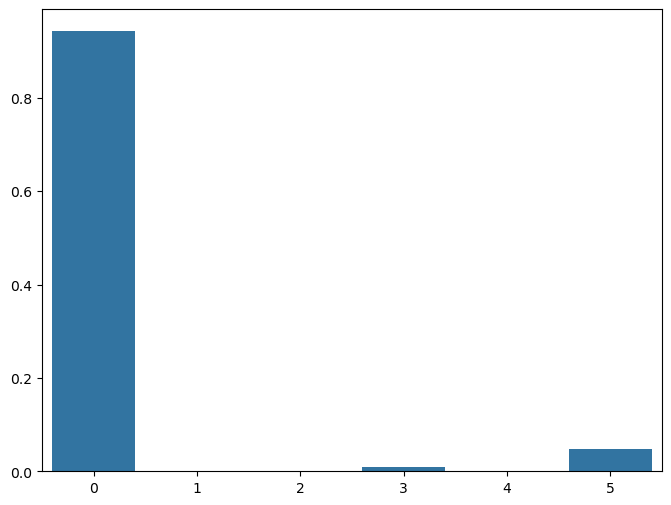

In [370]:
plt.figure(figsize=(8, 6))
sns.barplot(model.feature_importances_)
plt.show()

In [77]:

X_test.drop(['order_size', 'weight_kg', ], axis=1, inplace=True)

In [142]:
model = DecisionTreeRegressor(max_depth=3, max_features=5, min_samples_split=8)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(mean_absolute_error(y_pred, y_test))

2.528668676507999


In [144]:
X_train

,distance_km,warehouse_load,traffic_index,weather_score
3749,153.644982,0.835244,5,0.534282
2501,176.187473,0.629219,2,0.733192
1660,428.765304,0.634055,6,0.591104
987,392.587981,0.527588,1,0.765041
3448,380.425665,0.170760,6,0.408391
...,...,...,...,...
2817,171.365463,0.404911,6,0.472529
1113,431.773761,0.961418,2,0.849167
641,222.426216,0.003122,6,0.394858
167,100.466844,0.807831,5,0.298276


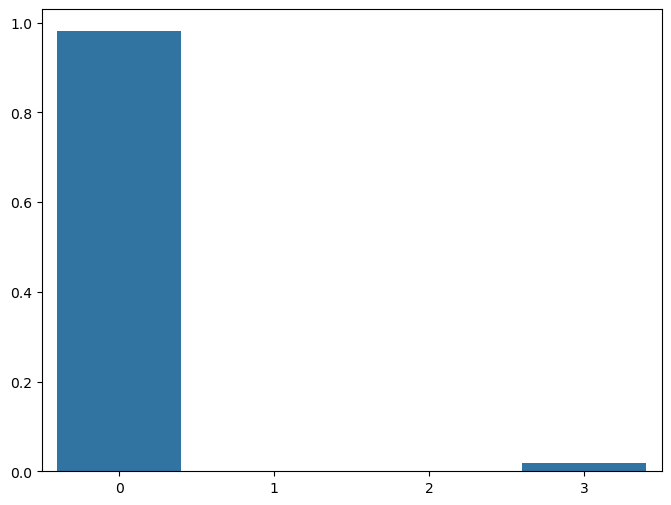

In [143]:
plt.figure(figsize=(8, 6))
sns.barplot(model.feature_importances_)
plt.show()

In [456]:
res = np.array([0] * n)
res[0] = [1, 2]

ValueError: setting an array element with a sequence.

In [453]:
n = 100
res = np.array([0] * n)
params = np.array([0] * n)
pr1 = 0
pr2 = 0
model = DecisionTreeRegressor(criterion='absolute_error', max_depth=4)
for i in tqdm(range(100)):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    res[i] = mean_absolute_error(y_pred, y_test)
    params[i] = np.array(model.feature_importances_)
    pr1 += model.feature_importances_[1]
    pr2 += model.feature_importances_[2]

  0%|          | 0/100 [00:00<?, ?it/s]

ValueError: setting an array element with a sequence.

1.9876909059228363
0.0
0.05608956761174835


array([0.92591566, 0.        , 0.0021113 , 0.00221684, 0.00431577,
       0.06544043])

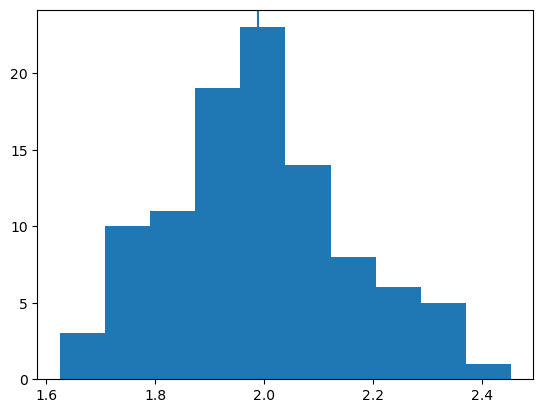

In [448]:
plt.hist(np.arrayres)
plt.axvline(np.mean(res))
print(np.mean(res))
print(pr1)
print(pr2)
model.feature_importances_

In [445]:
model.feature_importances_[2]

0.0

  0%|          | 0/100 [00:00<?, ?it/s]

(array([ 9., 50., 37.,  3.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([1.6057041 , 1.87255409, 2.13940409, 2.40625409, 2.67310408,
        2.93995408, 3.20680408, 3.47365407, 3.74050407, 4.00735407,
        4.27420406]),
 <BarContainer object of 10 artists>)

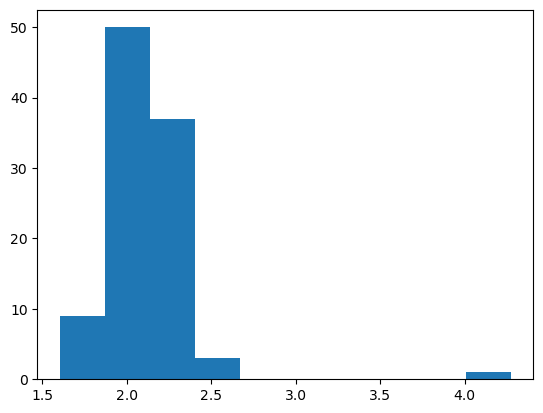

In [433]:
res = []
model = DecisionTreeRegressor(max_depth=3, max_features=5, min_samples_split=8, criterion='absolute_error')
for i in tqdm(range(100)):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    res.append(mean_absolute_error(y_pred, y_test))


In [438]:
res = np.array(res)[np.array(res) < 3]

2.0869282146865653

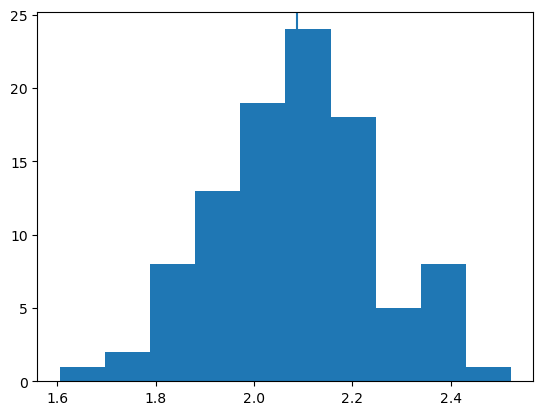

In [439]:
plt.hist(res)
plt.axvline(np.mean(res))
np.mean(res)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:17<00:00,  5.62it/s]


MAE over 100 runs: 1.9867 ± 0.1669
Mean feature importances:
 feature 0: 0.9265 ± 0.0032
 feature 1: 0.0000 ± 0.0000
 feature 2: 0.0007 ± 0.0014
 feature 3: 0.0012 ± 0.0011
 feature 4: 0.0046 ± 0.0008
 feature 5: 0.0669 ± 0.0027


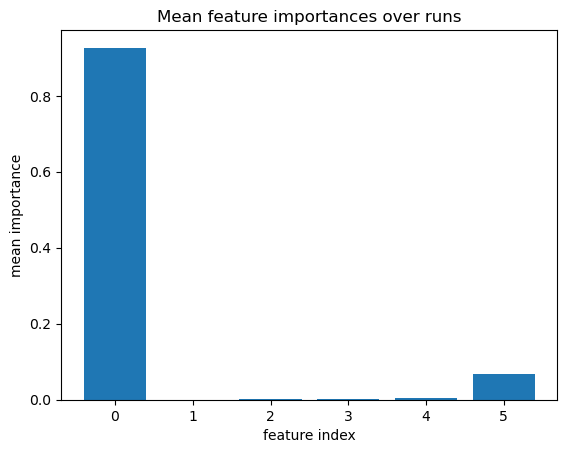

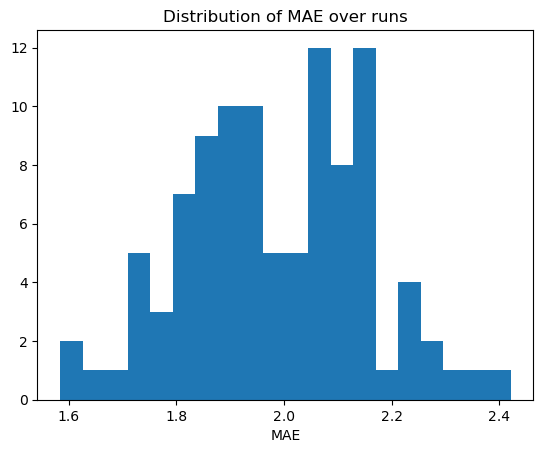

In [457]:
n_runs = 100

model = DecisionTreeRegressor(criterion='absolute_error', max_depth=4, random_state=42)

n_features = X.shape[1]

res = np.zeros(n_runs, dtype=float)
params = np.zeros((n_runs, n_features), dtype=float)

accum_importances = np.zeros(n_features, dtype=float)

for i in tqdm(range(n_runs)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i, shuffle=True
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res[i] = mean_absolute_error(y_test, y_pred)

    fi = model.feature_importances_
    params[i, :] = fi

    accum_importances += fi

mae_mean = res.mean()
mae_std = res.std()
mean_importances = params.mean(axis=0)
std_importances = params.std(axis=0)

print(f"MAE over {n_runs} runs: {mae_mean:.4f} ± {mae_std:.4f}")
print("Mean feature importances:")
for idx, (m, s) in enumerate(zip(mean_importances, std_importances)):
    print(f" feature {idx}: {m:.4f} ± {s:.4f}")

plt.bar(range(n_features), mean_importances)
plt.xlabel("feature index")
plt.ylabel("mean importance")
plt.title("Mean feature importances over runs")
plt.show()

plt.hist(res, bins=20)
plt.xlabel("MAE")
plt.title("Distribution of MAE over runs")
plt.show()

In [467]:
print(params[:, 2].mean())

0.0007082470390354926

In [464]:
params[13]

array([0.93188335, 0.        , 0.00168889, 0.        , 0.        ,
       0.06642776])

In [462]:
res


array([1.94176569, 2.16769432, 2.07460619, 1.83260144, 1.74113245,
       2.15577144, 1.95917281, 1.81130749, 2.07571148, 2.06724599,
       2.11838125, 1.86722575, 1.78936356, 1.58416324, 2.16764267,
       1.82263813, 2.03600058, 1.95853066, 1.96064297, 1.98721969,
       2.04110712, 2.16384657, 2.04731974, 1.71236939, 2.0620414 ,
       2.12224678, 1.87280684, 2.02001781, 1.89565661, 2.13045672,
       2.09540952, 2.09622119, 1.91637604, 1.88348731, 1.88268838,
       1.9099945 , 2.07500079, 2.13069212, 1.86370324, 2.05664623,
       1.90046059, 2.31760914, 1.79983485, 1.86885954, 2.08879645,
       2.06114837, 1.88653826, 2.05855633, 2.10132562, 2.06633405,
       1.82716741, 2.13612791, 1.7436813 , 1.87496813, 1.77346584,
       1.83739179, 2.22722402, 1.81907952, 1.64141396, 1.78496271,
       1.93423284, 1.73441423, 2.1504449 , 1.84602322, 2.25870107,
       2.13414668, 1.82735105, 1.99245809, 1.95849893, 1.84116855,
       1.69516963, 1.99036456, 2.05009249, 1.73305751, 2.36454

In [475]:
X = X.drop(['order_size'], axis=1)

KeyError: "['order_size'] not found in axis"

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:45<00:00,  6.04it/s]


MAE over 1000 runs: 1.9810 ± 0.1666
Mean feature importances:
 feature 0: 0.9267 ± 0.0033
 feature 1: 0.0007 ± 0.0013
 feature 2: 0.0013 ± 0.0012
 feature 3: 0.0046 ± 0.0010
 feature 4: 0.0667 ± 0.0030


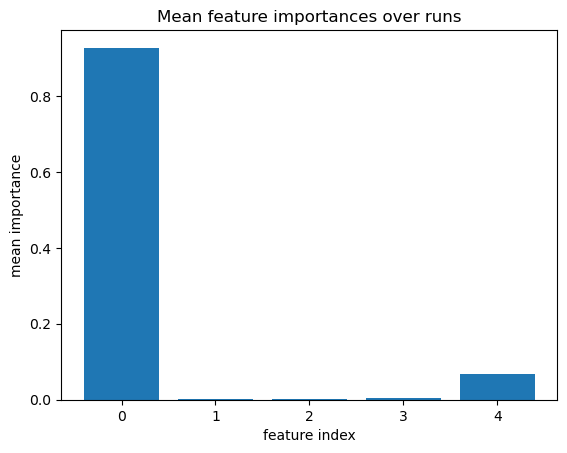

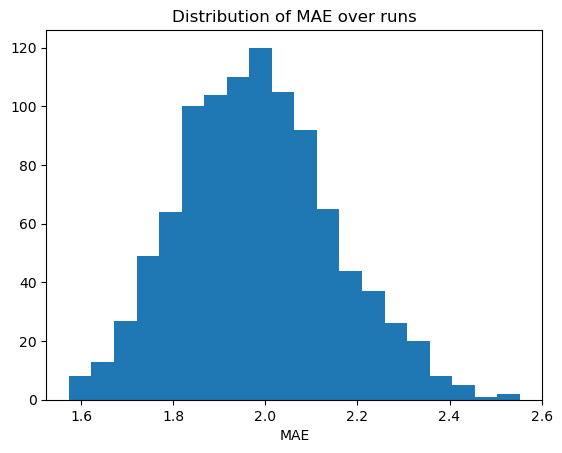

In [476]:
n_runs = 1000

model = DecisionTreeRegressor(criterion='absolute_error', max_depth=4, random_state=42)

n_features = X.shape[1]

res = np.zeros(n_runs, dtype=float)
params = np.zeros((n_runs, n_features), dtype=float)

accum_importances = np.zeros(n_features, dtype=float)

for i in tqdm(range(n_runs)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i, shuffle=True
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res[i] = mean_absolute_error(y_test, y_pred)

    fi = model.feature_importances_
    params[i, :] = fi

    accum_importances += fi

mae_mean = res.mean()
mae_std = res.std()
mean_importances = params.mean(axis=0)
std_importances = params.std(axis=0)

print(f"MAE over {n_runs} runs: {mae_mean:.4f} ± {mae_std:.4f}")
print("Mean feature importances:")
for idx, (m, s) in enumerate(zip(mean_importances, std_importances)):
    print(f" feature {idx}: {m:.4f} ± {s:.4f}")

plt.bar(range(n_features), mean_importances)
plt.xlabel("feature index")
plt.ylabel("mean importance")
plt.title("Mean feature importances over runs")
plt.show()

plt.hist(res, bins=20)
plt.xlabel("MAE")
plt.title("Distribution of MAE over runs")
plt.show()

In [501]:
mask = params[:, 1] > 0
print(params[mask, :])
print(res[mask].mean())

[[0.92251907 0.00456639 0.00210157 0.00442279 0.06639018]
 [0.92455838 0.00129499 0.         0.00415975 0.06998689]
 [0.93188335 0.00168889 0.         0.         0.06642776]
 ...
 [0.92745897 0.00143161 0.00203231 0.00414014 0.06493698]
 [0.92534984 0.00201015 0.         0.00413553 0.06850448]
 [0.93177155 0.00120527 0.         0.00458667 0.0624365 ]]
1.980896374652025


In [490]:
X

,distance_km,weight_kg,warehouse_load,traffic_index,weather_score
0,320.482764,17.890467,0.890303,6,0.331593
1,23.598351,11.742566,0.948053,2,0.408812
2,353.619317,16.779406,0.299423,3,0.573276
3,24.807187,11.907949,0.135933,4,0.609499
4,365.124595,18.612164,0.809789,4,0.539672
...,...,...,...,...,...
3995,118.461997,18.230803,0.285405,2,0.522663
3996,142.856043,17.887255,0.777728,5,0.388616
3997,199.517659,18.099324,0.585863,3,0.626159
3998,171.978843,18.628791,0.556236,3,0.703528


In [3]:
df = df_train.copy()
df['dist_log'] = np.log1p(df['distance_km'])
df['dist_x_traffic'] = df['distance_km'] * df['traffic_index']
df['weight_dist'] = df['distance_km'] * df['weight_kg']
df['load_dist'] = df['distance_km'] * df['warehouse_load']
df['traffic_dist'] = df['distance_km'] * df['traffic_index']
df['dist_sqrt'] = np.power(df['distance_km'], 0.5)

In [4]:
df

,id,distance_km,order_size,weight_kg,warehouse_load,traffic_index,weather_score,delivery_time_days,dist_log,dist_x_traffic,weight_dist,load_dist,traffic_dist,dist_sqrt
0,4227,320.482764,6,17.890467,0.890303,6,0.331593,15.078251,5.772944,1922.896584,5733.586376,285.326624,1922.896584,17.902032
1,4676,23.598351,4,11.742566,0.948053,2,0.408812,5.854297,3.202679,47.196702,277.105196,22.372494,47.196702,4.857813
2,800,353.619317,4,16.779406,0.299423,3,0.573276,13.199098,5.871045,1060.857951,5933.521956,105.881801,1060.857951,18.804768
3,3671,24.807187,4,11.907949,0.135933,4,0.609499,36.064467,3.250653,99.228747,295.402715,3.372109,99.228747,4.980681
4,4193,365.124595,6,18.612164,0.809789,4,0.539672,15.568615,5.902974,1460.498379,6795.759010,295.673708,1460.498379,19.108234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,4426,118.461997,6,18.230803,0.285405,2,0.522663,5.763228,4.782998,236.923994,2159.657337,33.809681,236.923994,10.884025
3996,466,142.856043,5,17.887255,0.777728,5,0.388616,46.425502,4.968813,714.280216,2555.302478,111.103132,714.280216,11.952240
3997,3092,199.517659,6,18.099324,0.585863,3,0.626159,8.706341,5.300902,598.552976,3611.134830,116.890024,598.552976,14.125072
3998,3772,171.978843,6,18.628791,0.556236,3,0.703528,8.203242,5.153169,515.936530,3203.757973,95.660892,515.936530,13.114070


In [5]:
y = df.loc[:, ['delivery_time_days']]
X = df.drop(['delivery_time_days', 'id'], axis=1)

In [8]:
X = X.drop(['order_size', 'weight_kg', 'warehouse_load', 'traffic_index'], axis=1)

In [11]:
X = X.drop(['dist_x_traffic', 'dist_sqrt'], axis=1)

  0%|          | 0/100 [00:00<?, ?it/s]

MAE over 100 runs: 1.9515 ± 0.1704
Mean feature importances:
 feature 0: 0.8317 ± 0.0531
 feature 1: 0.0634 ± 0.0038
 feature 2: 0.0381 ± 0.0467
 feature 3: 0.0357 ± 0.0055
 feature 4: 0.0141 ± 0.0037
 feature 5: 0.0170 ± 0.0135


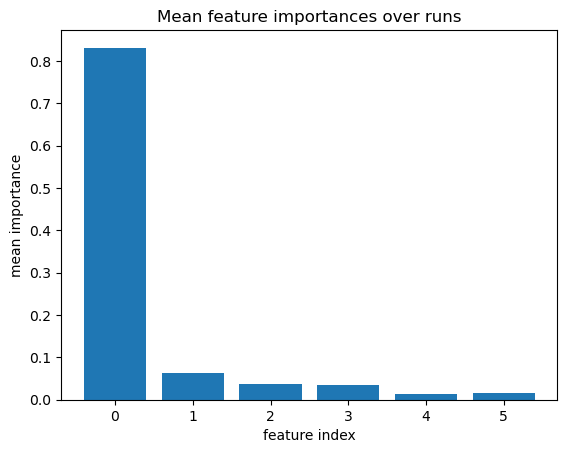

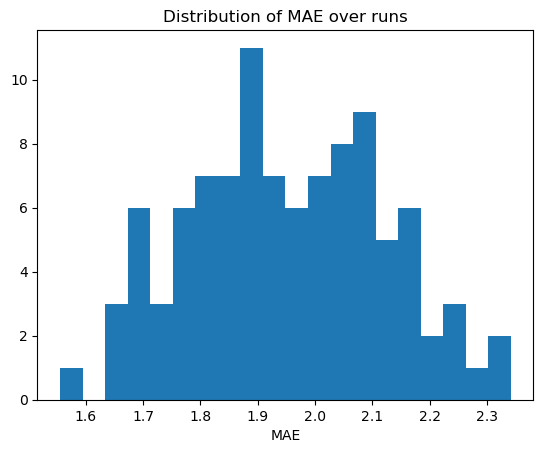

In [12]:
n_runs = 100

model = DecisionTreeRegressor(criterion='absolute_error', max_depth=5, random_state=42)

n_features = X.shape[1]

res = np.zeros(n_runs, dtype=float)
params = np.zeros((n_runs, n_features), dtype=float)

accum_importances = np.zeros(n_features, dtype=float)

for i in tqdm(range(n_runs)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i, shuffle=True
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res[i] = mean_absolute_error(y_test, y_pred)

    fi = model.feature_importances_
    params[i, :] = fi

    accum_importances += fi

mae_mean = res.mean()
mae_std = res.std()
mean_importances = params.mean(axis=0)
std_importances = params.std(axis=0)

print(f"MAE over {n_runs} runs: {mae_mean:.4f} ± {mae_std:.4f}")
print("Mean feature importances:")
for idx, (m, s) in enumerate(zip(mean_importances, std_importances)):
    print(f" feature {idx}: {m:.4f} ± {s:.4f}")

plt.bar(range(n_features), mean_importances)
plt.xlabel("feature index")
plt.ylabel("mean importance")
plt.title("Mean feature importances over runs")
plt.show()

plt.hist(res, bins=20)
plt.xlabel("MAE")
plt.title("Distribution of MAE over runs")
plt.show()

In [13]:
X

,distance_km,weather_score,dist_log,weight_dist,load_dist,traffic_dist
0,320.482764,0.331593,5.772944,5733.586376,285.326624,1922.896584
1,23.598351,0.408812,3.202679,277.105196,22.372494,47.196702
2,353.619317,0.573276,5.871045,5933.521956,105.881801,1060.857951
3,24.807187,0.609499,3.250653,295.402715,3.372109,99.228747
4,365.124595,0.539672,5.902974,6795.759010,295.673708,1460.498379
...,...,...,...,...,...,...
3995,118.461997,0.522663,4.782998,2159.657337,33.809681,236.923994
3996,142.856043,0.388616,4.968813,2555.302478,111.103132,714.280216
3997,199.517659,0.626159,5.300902,3611.134830,116.890024,598.552976
3998,171.978843,0.703528,5.153169,3203.757973,95.660892,515.936530


In [509]:
param_grid = {'max_depth':range(1, 20),
              'min_samples_split':range(2, 11),
              'criterion':['absolute_error']
             }
grid_model = GridSearchCV(estimator=DecisionTreeRegressor(), 
                     param_grid=param_grid,
                     n_jobs=-1)

grid_model.fit(X_train, y_train)

C:\Users\ASUS\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['absolute_error'],
                         'max_depth': range(1, 20),
                         'min_samples_split': range(2, 11)})

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:28<00:00,  3.54it/s]

MAE over 100 runs: 1.9531 ± 0.1688
Mean feature importances:
 feature 0: 0.1245 ± 0.0258
 feature 1: 0.0003 ± 0.0006
 feature 2: 0.0016 ± 0.0020
 feature 3: 0.0066 ± 0.0026
 feature 4: 0.0034 ± 0.0030
 feature 5: 0.0638 ± 0.0040
 feature 6: 0.7477 ± 0.0270
 feature 7: 0.0172 ± 0.0140
 feature 8: 0.0350 ± 0.0063


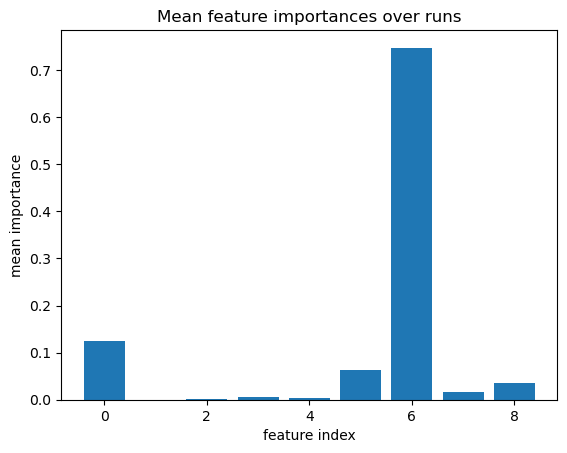

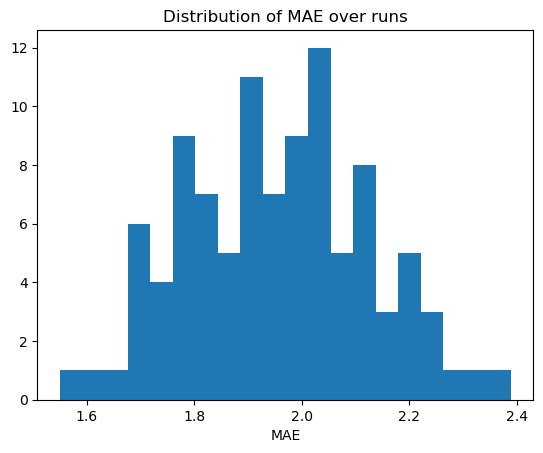

In [511]:
n_runs = 100

model = DecisionTreeRegressor(criterion='absolute_error', max_depth=5, random_state=42)

n_features = X.shape[1]

res = np.zeros(n_runs, dtype=float)
params = np.zeros((n_runs, n_features), dtype=float)

accum_importances = np.zeros(n_features, dtype=float)

for i in tqdm(range(n_runs)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i, shuffle=True
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res[i] = mean_absolute_error(y_test, y_pred)

    fi = model.feature_importances_
    params[i, :] = fi

    accum_importances += fi

mae_mean = res.mean()
mae_std = res.std()
mean_importances = params.mean(axis=0)
std_importances = params.std(axis=0)

print(f"MAE over {n_runs} runs: {mae_mean:.4f} ± {mae_std:.4f}")
print("Mean feature importances:")
for idx, (m, s) in enumerate(zip(mean_importances, std_importances)):
    print(f" feature {idx}: {m:.4f} ± {s:.4f}")

plt.bar(range(n_features), mean_importances)
plt.xlabel("feature index")
plt.ylabel("mean importance")
plt.title("Mean feature importances over runs")
plt.show()

plt.hist(res, bins=20)
plt.xlabel("MAE")
plt.title("Distribution of MAE over runs")
plt.show()

In [512]:
X

,distance_km,order_size,weight_kg,warehouse_load,traffic_index,weather_score,dist_log,dist_x_traffic,weight_dist
0,320.482764,6,17.890467,0.890303,6,0.331593,5.772944,1922.896584,5733.586376
1,23.598351,4,11.742566,0.948053,2,0.408812,3.202679,47.196702,277.105196
2,353.619317,4,16.779406,0.299423,3,0.573276,5.871045,1060.857951,5933.521956
3,24.807187,4,11.907949,0.135933,4,0.609499,3.250653,99.228747,295.402715
4,365.124595,6,18.612164,0.809789,4,0.539672,5.902974,1460.498379,6795.759010
...,...,...,...,...,...,...,...,...,...
3995,118.461997,6,18.230803,0.285405,2,0.522663,4.782998,236.923994,2159.657337
3996,142.856043,5,17.887255,0.777728,5,0.388616,4.968813,714.280216,2555.302478
3997,199.517659,6,18.099324,0.585863,3,0.626159,5.300902,598.552976,3611.134830
3998,171.978843,6,18.628791,0.556236,3,0.703528,5.153169,515.936530,3203.757973


In [516]:
X = X.drop(['order_size', 'weight_kg', 'warehouse_load', 'traffic_index'], axis=1)

In [528]:
X

,distance_km,weather_score,dist_log,dist_x_traffic,weight_dist
0,320.482764,0.331593,5.772944,1922.896584,5733.586376
1,23.598351,0.408812,3.202679,47.196702,277.105196
2,353.619317,0.573276,5.871045,1060.857951,5933.521956
3,24.807187,0.609499,3.250653,99.228747,295.402715
4,365.124595,0.539672,5.902974,1460.498379,6795.759010
...,...,...,...,...,...
3995,118.461997,0.522663,4.782998,236.923994,2159.657337
3996,142.856043,0.388616,4.968813,714.280216,2555.302478
3997,199.517659,0.626159,5.300902,598.552976,3611.134830
3998,171.978843,0.703528,5.153169,515.936530,3203.757973


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:18<00:00,  5.36it/s]

MAE over 100 runs: 1.9448 ± 0.1696
Mean feature importances:
 feature 0: 0.8119 ± 0.0376
 feature 1: 0.0647 ± 0.0042
 feature 2: 0.0639 ± 0.0407
 feature 3: 0.0216 ± 0.0132
 feature 4: 0.0379 ± 0.0061


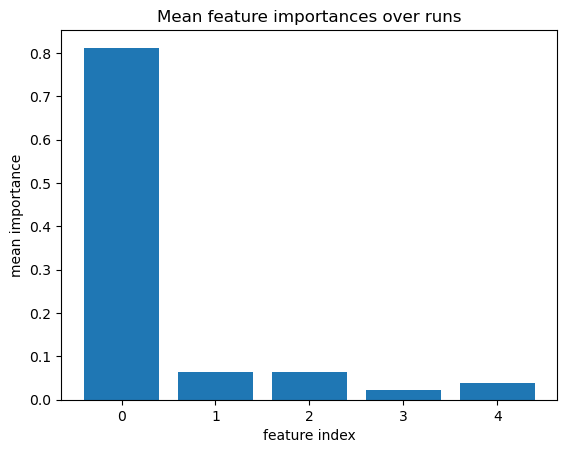

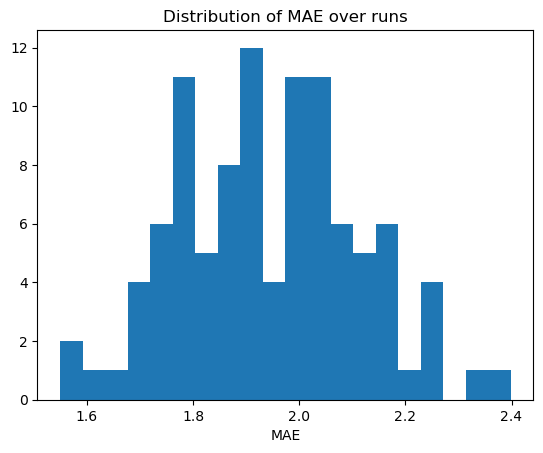

In [529]:
n_runs = 100

model = DecisionTreeRegressor(criterion='absolute_error', max_depth=5, random_state=42)

n_features = X.shape[1]

res = np.zeros(n_runs, dtype=float)
params = np.zeros((n_runs, n_features), dtype=float)

accum_importances = np.zeros(n_features, dtype=float)

for i in tqdm(range(n_runs)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i, shuffle=True
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res[i] = mean_absolute_error(y_test, y_pred)

    fi = model.feature_importances_
    params[i, :] = fi

    accum_importances += fi

mae_mean = res.mean()
mae_std = res.std()
mean_importances = params.mean(axis=0)
std_importances = params.std(axis=0)

print(f"MAE over {n_runs} runs: {mae_mean:.4f} ± {mae_std:.4f}")
print("Mean feature importances:")
for idx, (m, s) in enumerate(zip(mean_importances, std_importances)):
    print(f" feature {idx}: {m:.4f} ± {s:.4f}")

plt.bar(range(n_features), mean_importances)
plt.xlabel("feature index")
plt.ylabel("mean importance")
plt.title("Mean feature importances over runs")
plt.show()

plt.hist(res, bins=20)
plt.xlabel("MAE")
plt.title("Distribution of MAE over runs")
plt.show()

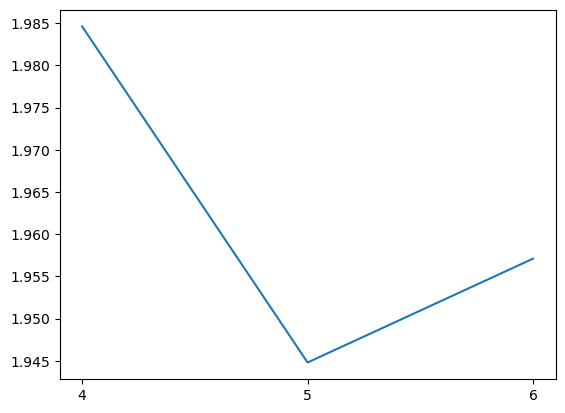

In [527]:
depths = [4, 5, 6]
maes = [1.9846, 1.9448, 1.9571]
plt.plot(depths, maes)
plt.xticks(depths)
plt.show()

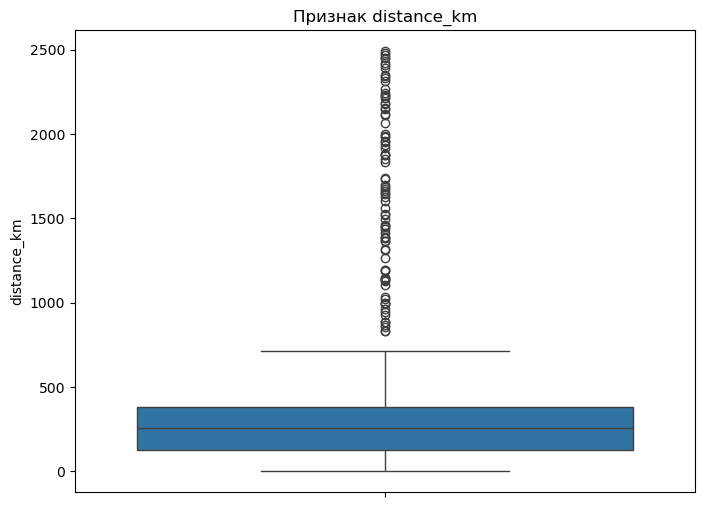

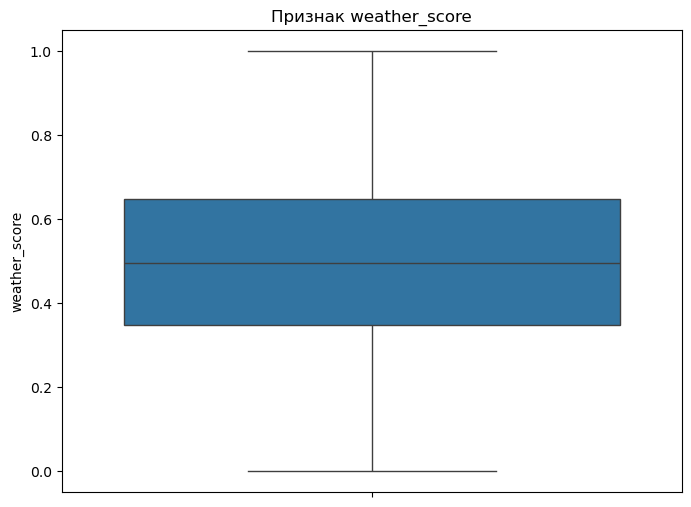

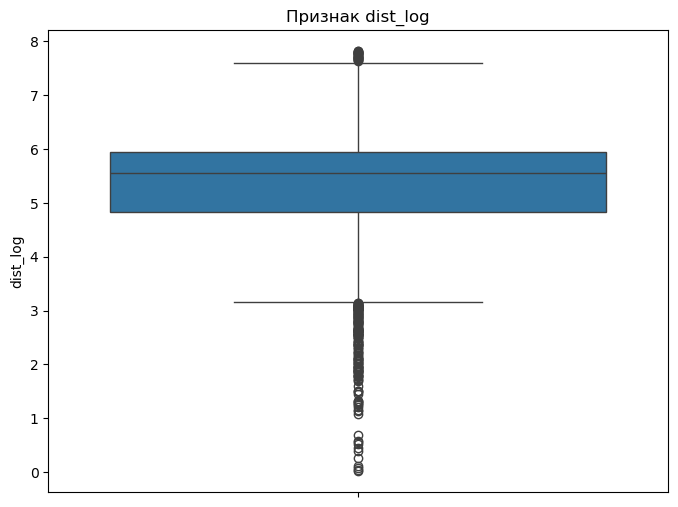

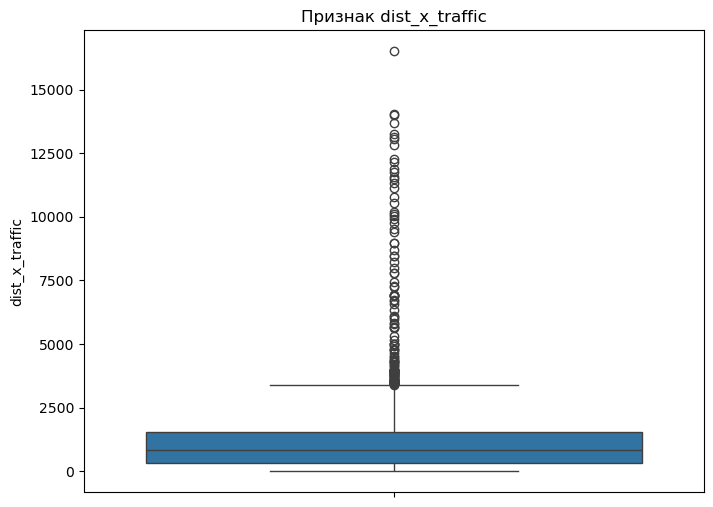

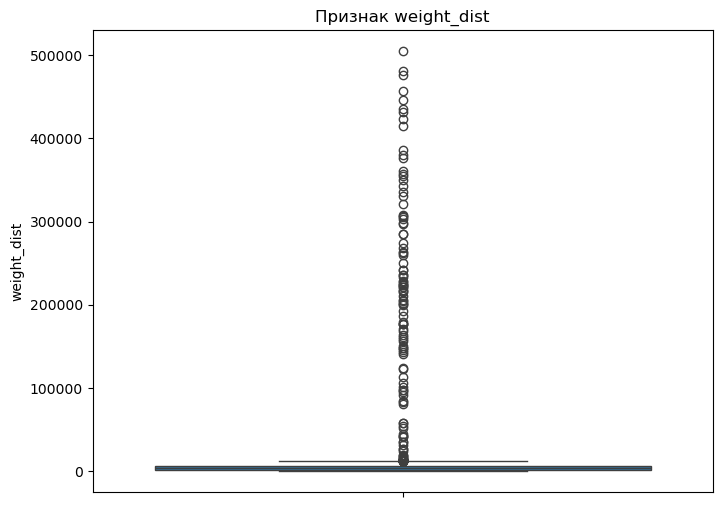

In [534]:
for column in X.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(X[column])
    plt.title(f'Признак {column}')
    plt.show()